# Комплексный анализ данных (EDA)
### House Prices Dataset — полный цикл Exploratory Data Analysis
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

---


## Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler


---
## Шаг 1: Загрузка и первичный осмотр

In [2]:
df = pd.read_csv('datasets/house_prices.csv')
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Размер: 1460 строк, 81 колонок


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(f"Числовых колонок:       {df.select_dtypes(include=np.number).shape[1]}")
print(f"Категориальных колонок: {df.select_dtypes(include='object').shape[1]}")
print()
df.info()

Числовых колонок:       38
Категориальных колонок: 43

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 1

---
## Шаг 2: Анализ целевой переменной — SalePrice

Всегда начинаем с целевой переменной — именно её мы хотим понять и предсказать.

In [4]:
sp = df['SalePrice']

print("=== Описательная статистика SalePrice ===")
print(f"Mean:     ${sp.mean():>12,.0f}")
print(f"Median:   ${sp.median():>12,.0f}")
print(f"Std:      ${sp.std():>12,.0f}")
print(f"IQR:      ${sp.quantile(0.75) - sp.quantile(0.25):>12,.0f}")
print(f"Min:      ${sp.min():>12,.0f}")
print(f"Max:      ${sp.max():>12,.0f}")
print()
print(f"Skewness: {sp.skew():.4f}  ({'сильный правый скос' if sp.skew() > 1 else 'умеренный' if sp.skew() > 0.5 else 'норма'})")
print(f"Kurtosis: {sp.kurt():.4f}  (excess; нормальное = 0; {'leptokurtic - тяжёлые хвосты' if sp.kurt() > 0 else 'platykurtic'})")
print()
print(f"Mean > Median: {sp.mean() > sp.median()} → правый скос подтверждён")

=== Описательная статистика SalePrice ===
Mean:     $     180,921
Median:   $     163,000
Std:      $      79,443
IQR:      $      84,025
Min:      $      34,900
Max:      $     755,000

Skewness: 1.8829  (сильный правый скос)
Kurtosis: 6.5363  (excess; нормальное = 0; leptokurtic - тяжёлые хвосты)

Mean > Median: True → правый скос подтверждён


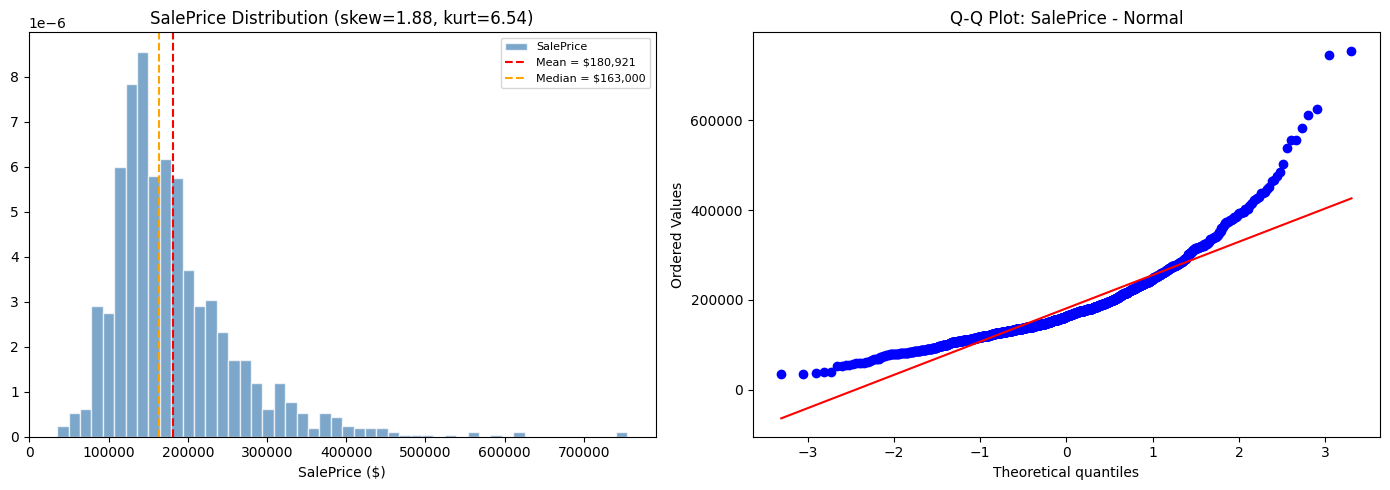

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sp, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white', label='SalePrice')
x = np.linspace(sp.min(), sp.max(), 300)
axes[0].axvline(sp.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = ${sp.mean():,.0f}')
axes[0].axvline(sp.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median = ${sp.median():,.0f}')
axes[0].set_title(f'SalePrice Distribution (skew={sp.skew():.2f}, kurt={sp.kurt():.2f})')
axes[0].set_xlabel('SalePrice ($)')
axes[0].legend(fontsize=8)

stats.probplot(sp, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: SalePrice - Normal')

plt.tight_layout()
plt.show()

---
## Шаг 3: Анализ пропущенных значений

In [6]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = pd.DataFrame({'Total': total, 'Percent (%)': percent.round(2)})
missing = missing[missing['Total'] > 0]
missing

,Total,Percent (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


C:\Users\kalys\AppData\Local\Temp\ipykernel_18868\4084062909.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(missing.index, rotation=45, ha='right')


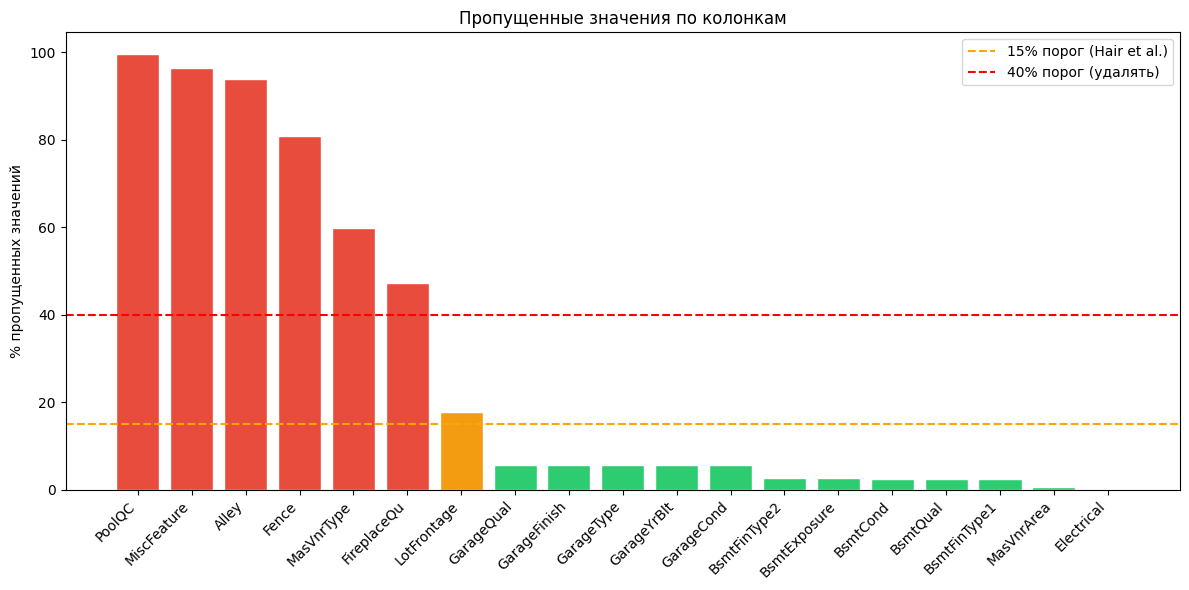

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if p > 40 else '#f39c12' if p > 15 else '#2ecc71'
          for p in missing['Percent (%)']]
bars = ax.bar(missing.index, missing['Percent (%)'], color=colors, edgecolor='white')
ax.axhline(y=15, color='orange', linestyle='--', linewidth=1.5, label='15% порог (Hair et al.)')
ax.axhline(y=40, color='red', linestyle='--', linewidth=1.5, label='40% порог (удалять)')
ax.set_xticklabels(missing.index, rotation=45, ha='right')
ax.set_ylabel('% пропущенных значений')
ax.set_title('Пропущенные значения по колонкам')
ax.legend()
plt.tight_layout()
plt.show()
print()

In [8]:
# Интерпретация пропусков: NaN = отсутствие признака
# PoolQC = NaN означает "нет бассейна"
# FireplaceQu = NaN означает "нет камина"

# Создаём бинарные признаки перед удалением
df_clean = df.copy()
df_clean['HasPool'] = (df_clean['PoolQC'].notna()).astype(int)
df_clean['HasFireplace'] = (df_clean['FireplaceQu'].notna()).astype(int)
df_clean['HasFence'] = (df_clean['Fence'].notna()).astype(int)
df_clean['HasAlley'] = (df_clean['Alley'].notna()).astype(int)

print(f"Домов с бассейном: {df_clean['HasPool'].sum()} ({df_clean['HasPool'].mean():.1%})")
print(f"Домов с камином:   {df_clean['HasFireplace'].sum()} ({df_clean['HasFireplace'].mean():.1%})")

# Применяем стратегию обработки пропусков
# Удаляем колонки с > 15% пропусков (кроме тех, где создали бинарный признак)
cols_to_drop = missing[missing['Percent (%)'] > 15].index.tolist()
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

# Удаляем строки с одиночными пропусками (< 5 строк)
df_clean = df_clean.dropna(subset=['Electrical'])

# Числовые: заполняем медианой
for col in df_clean.select_dtypes(include=np.number).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Категориальные: заполняем модой
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Размер: {df_clean.shape}")

Домов с бассейном: 7 (0.5%)
Домов с камином:   770 (52.7%)
Размер: (1459, 78)


---
## Шаг 4: Univariate Analysis

In [9]:
# Описательная статистика для числовых переменных с skewness и kurtosis
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Id']

stats_df = pd.DataFrame({
    'mean': df_clean[numeric_cols].mean(),
    'median': df_clean[numeric_cols].median(),
    'std': df_clean[numeric_cols].std(),
    'skewness': df_clean[numeric_cols].skew(),
    'kurtosis': df_clean[numeric_cols].kurt(),
    'missing_%': (df_clean[numeric_cols].isnull().sum() / len(df_clean) * 100)
})

# Самые скошенные признаки
print("Топ-10 признаков с наибольшим skewness:")
print(stats_df['skewness'].abs().sort_values(ascending=False).head(10))
print()
print("Топ-5 признаков с наибольшим kurtosis (leptokurtic - много выбросов):")
print(stats_df['kurtosis'].sort_values(ascending=False).head(5))

Топ-10 признаков с наибольшим skewness:
MiscVal         24.468441
PoolArea        14.823236
HasPool         14.347703
LotArea         12.203431
3SsnPorch       10.300725
LowQualFinSF     9.008149
KitchenAbvGr     4.486640
BsmtFinSF2       4.253594
ScreenPorch      4.120572
BsmtHalfBath     4.101759
Name: skewness, dtype: float64

Топ-5 признаков с наибольшим kurtosis (leptokurtic - много выбросов):
MiscVal      700.524315
PoolArea     223.112709
HasPool      204.136407
LotArea      203.101592
3SsnPorch    123.574970
Name: kurtosis, dtype: float64


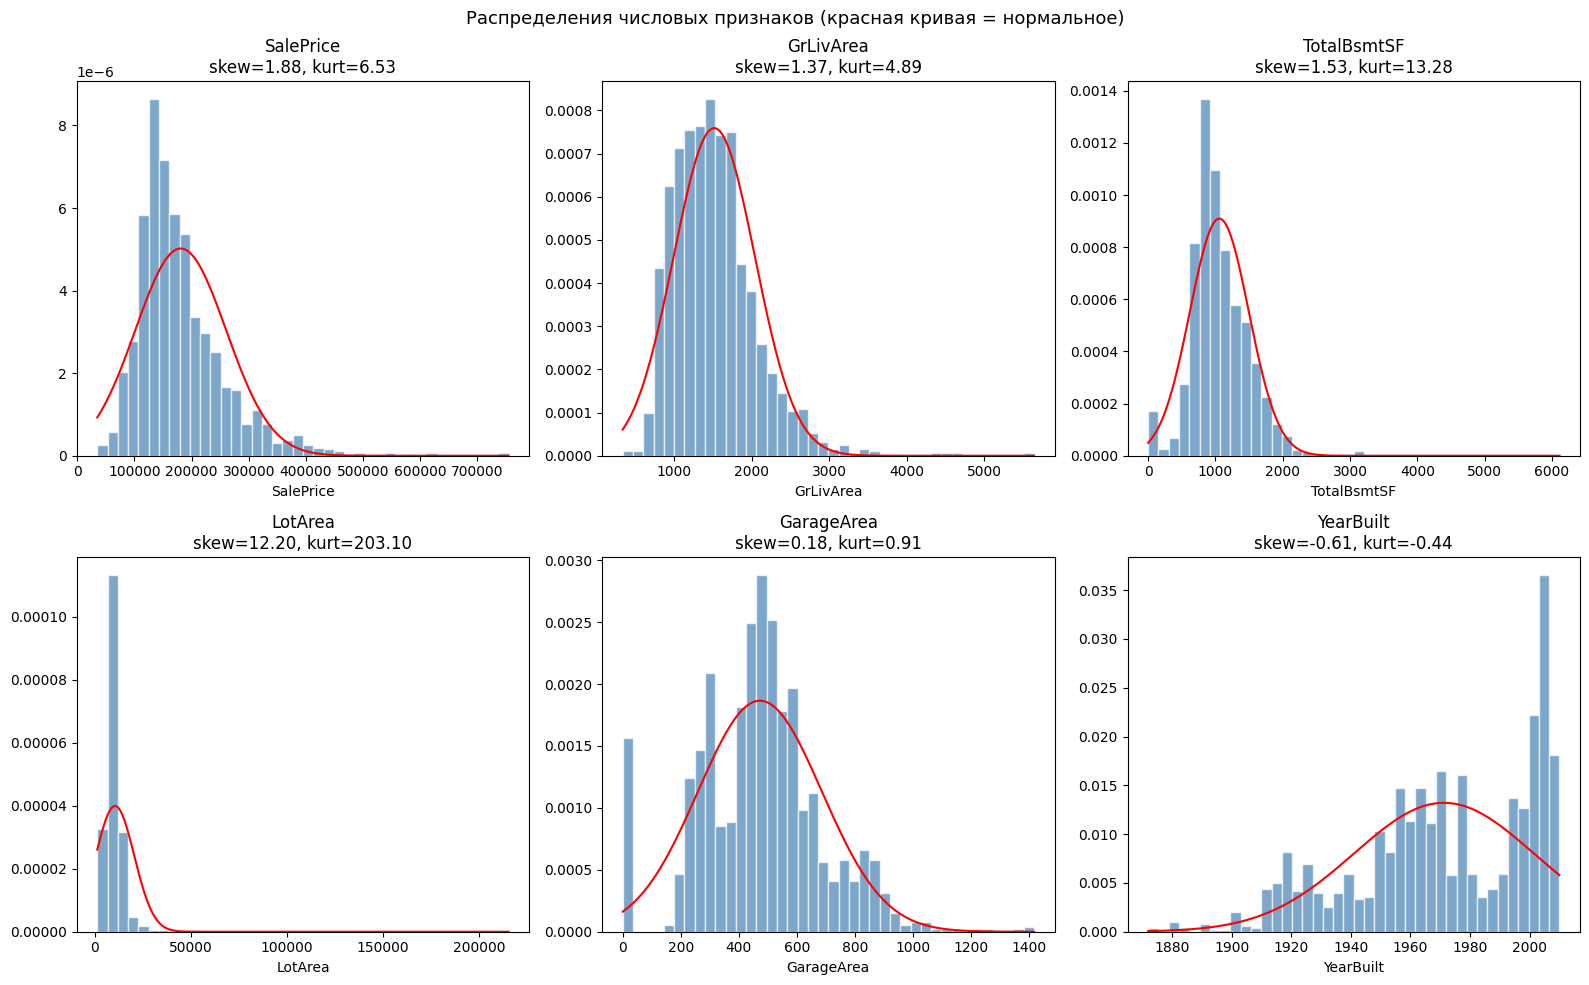

In [10]:
# Распределения ключевых числовых переменных
key_vars = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, key_vars):
    data = df_clean[col].dropna()
    ax.hist(data, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, norm.pdf(x, data.mean(), data.std()), 'r-', linewidth=1.5)
    ax.set_title(f'{col}\nskew={data.skew():.2f}, kurt={data.kurt():.2f}')
    ax.set_xlabel(col)

plt.suptitle('Распределения числовых признаков (красная кривая = нормальное)', fontsize=13)
plt.tight_layout()
plt.show()

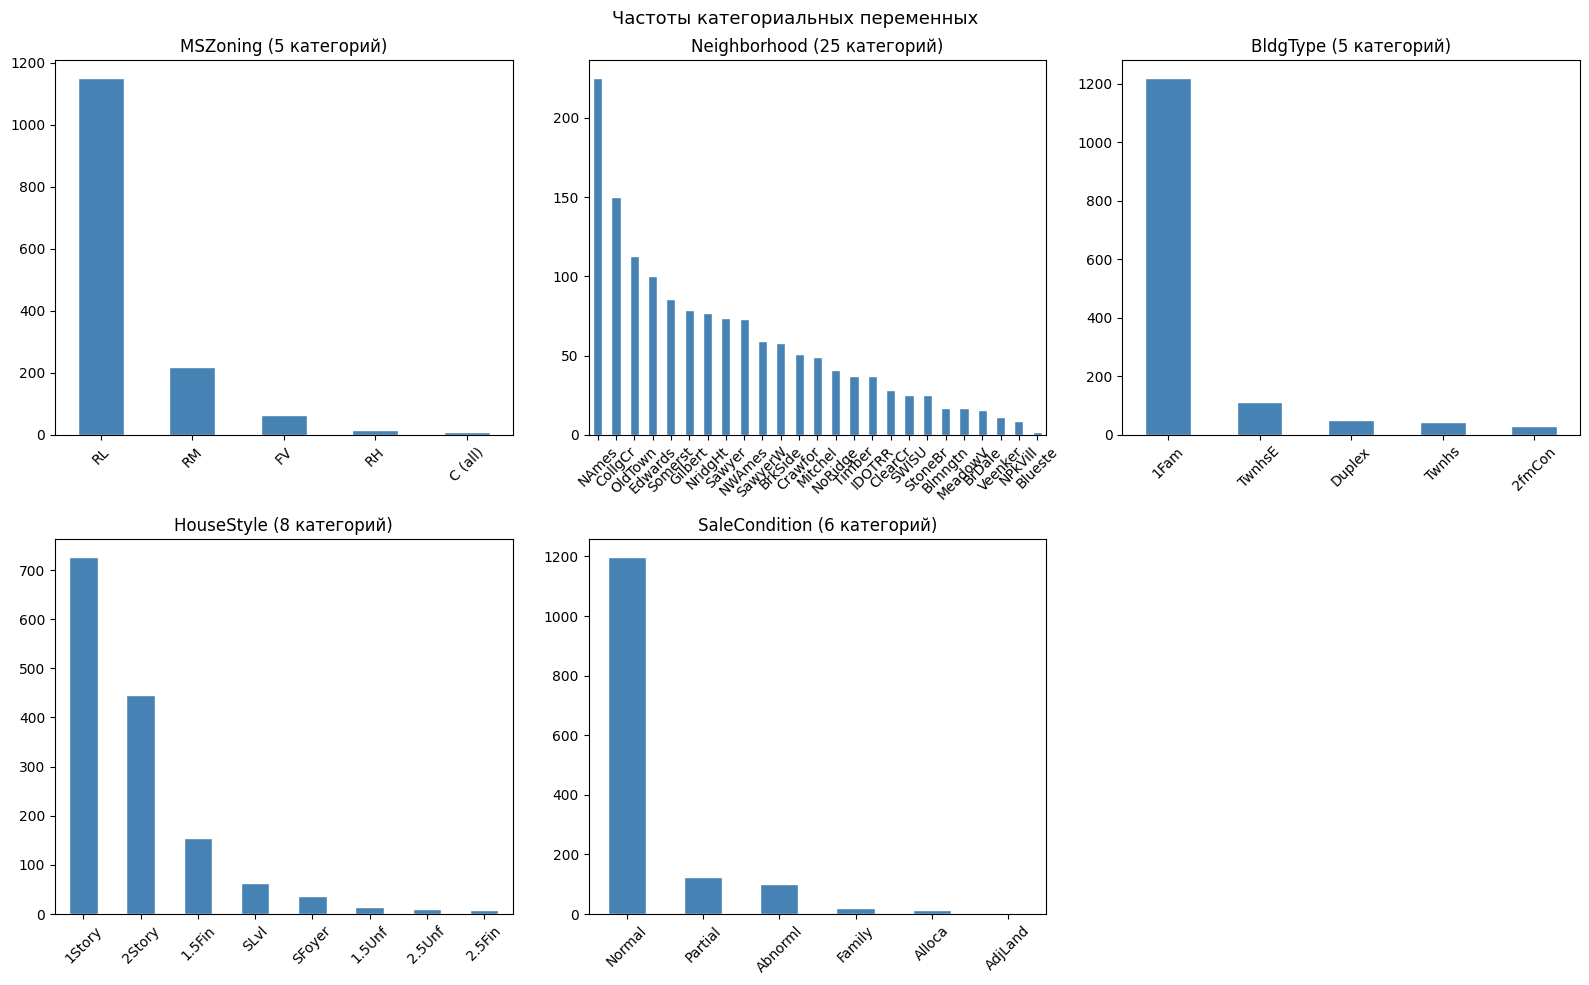

In [11]:
# Категориальные переменные
cat_vars = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle', 'SaleCondition']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_vars):
    vc = df_clean[col].value_counts()
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} ({df_clean[col].nunique()} категорий)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.suptitle('Частоты категориальных переменных', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 5: Bivariate Analysis - связь с SalePrice

### Числовые признаки и SalePrice

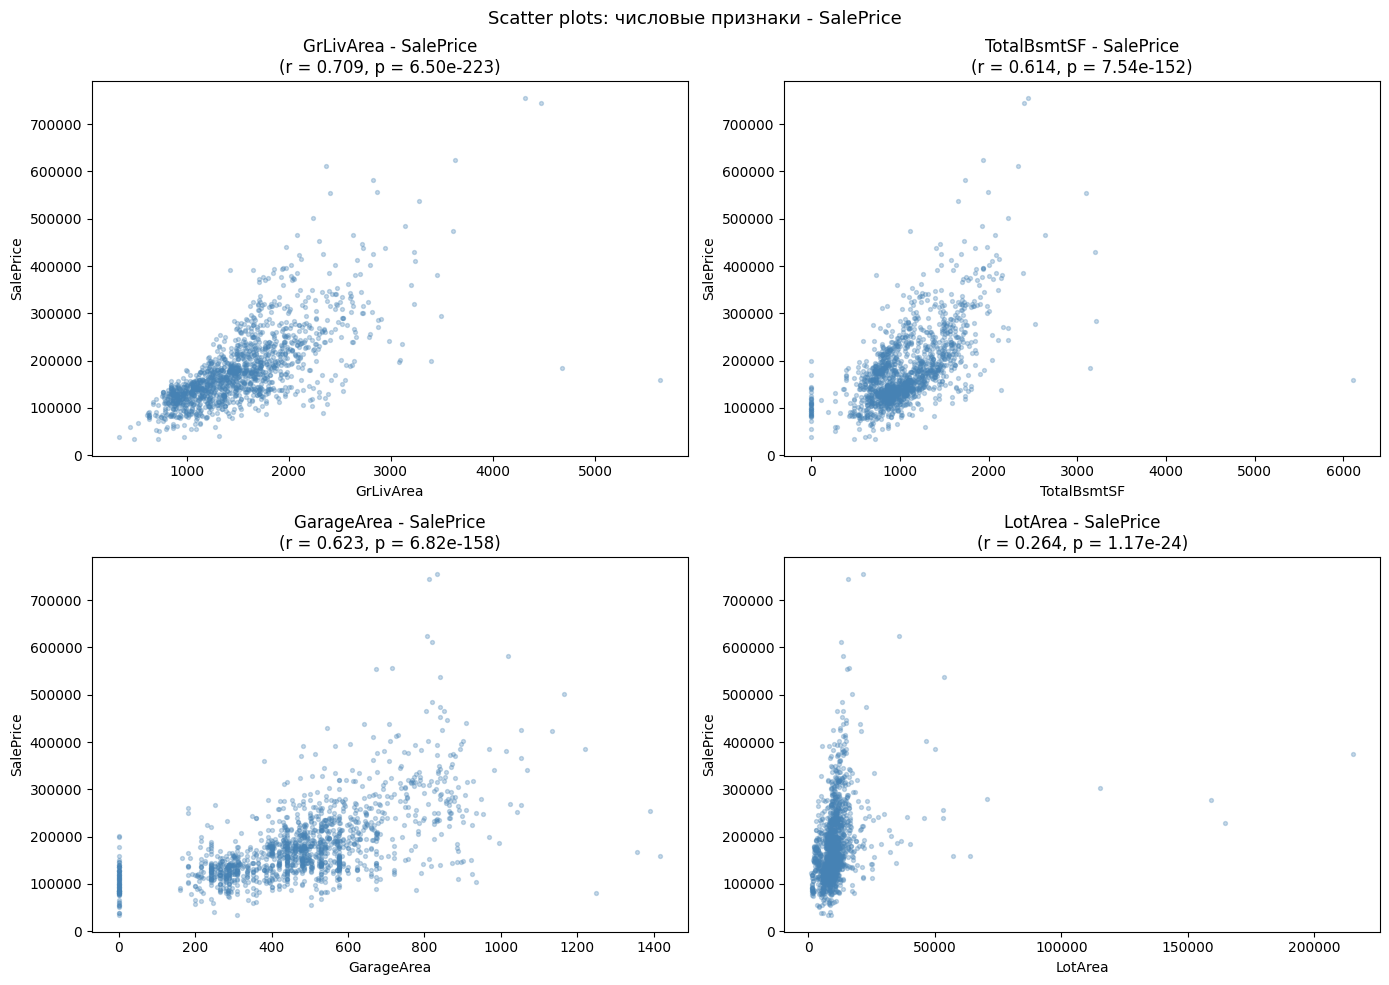

In [12]:
bivar_num = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, bivar_num):
    r, p = stats.pearsonr(df_clean[col].dropna(), df_clean.loc[df_clean[col].notna(), 'SalePrice'])
    ax.scatter(df_clean[col], df_clean['SalePrice'], alpha=0.3, s=8, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{col} - SalePrice\n(r = {r:.3f}, p = {p:.2e})')

plt.suptitle('Scatter plots: числовые признаки - SalePrice', fontsize=13)
plt.tight_layout()
plt.show()

### Категориальные признаки и SalePrice

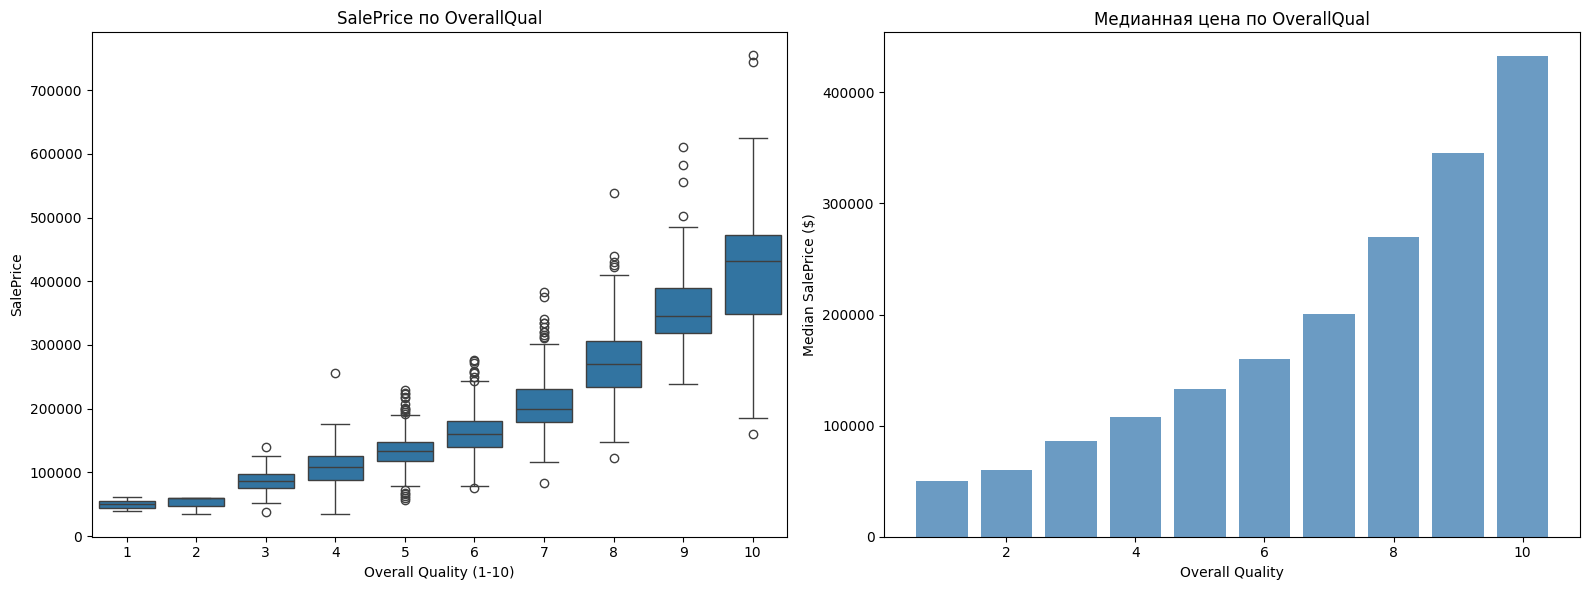

Диапазон медианных цен:
 OverallQual  SalePrice
           1    50150.0
           2    60000.0
           3    86250.0
           4   108000.0
           5   133000.0
           6   160000.0
           7   200141.0
           8   269750.0
           9   345000.0
          10   432390.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OverallQual - самый сильный предиктор
qual_order = sorted(df_clean['OverallQual'].unique())
sns.boxplot(x='OverallQual', y='SalePrice', data=df_clean, order=qual_order, ax=axes[0])
axes[0].set_title('SalePrice по OverallQual')
axes[0].set_xlabel('Overall Quality (1-10)')

# Группировка по среднему
qual_mean = df_clean.groupby('OverallQual')['SalePrice'].median().reset_index()
axes[1].bar(qual_mean['OverallQual'], qual_mean['SalePrice'], color='steelblue', alpha=0.8)
axes[1].set_title('Медианная цена по OverallQual')
axes[1].set_xlabel('Overall Quality')
axes[1].set_ylabel('Median SalePrice ($)')

plt.tight_layout()
plt.show()

print("Диапазон медианных цен:")
print(qual_mean.to_string(index=False))

C:\Users\kalys\AppData\Local\Temp\ipykernel_18868\2734736858.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)


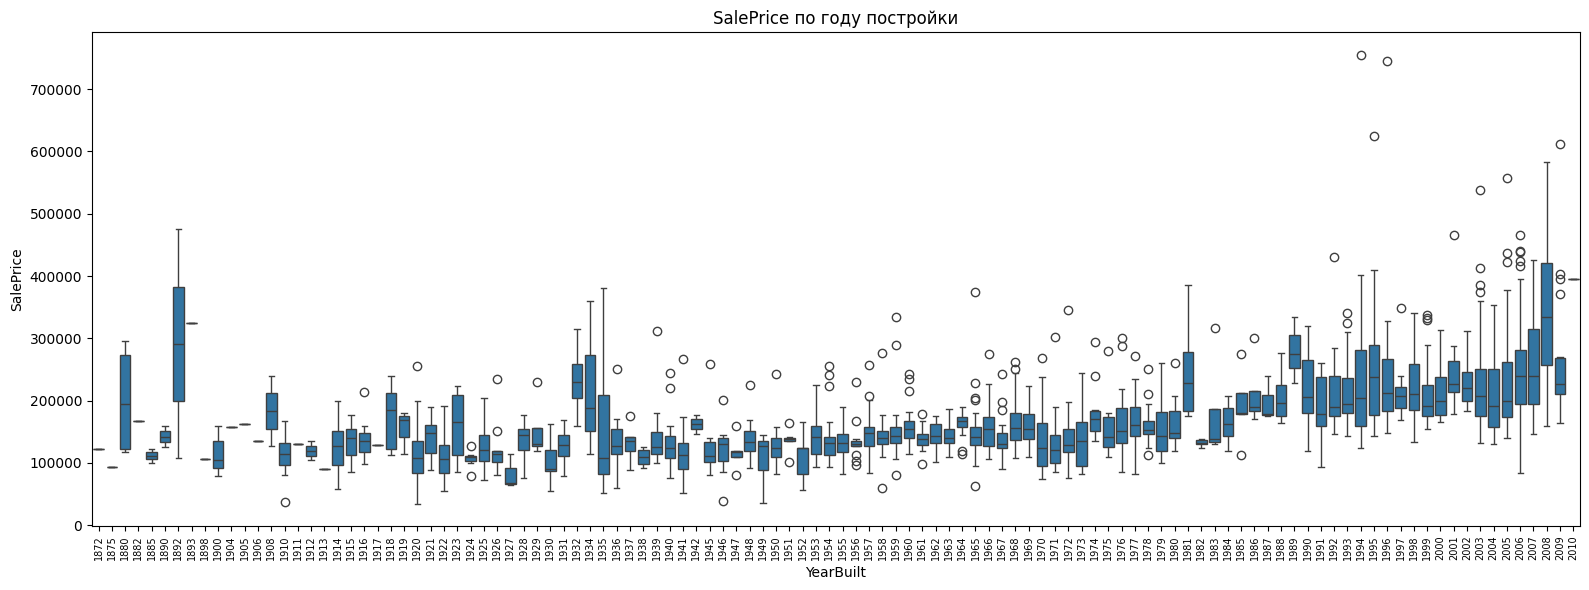

In [14]:
# YearBuilt - SalePrice
fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(x='YearBuilt', y='SalePrice', data=df_clean, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_title('SalePrice по году постройки')
plt.tight_layout()
plt.show()

---
## Шаг 6: Multivariate Analysis — корреляции

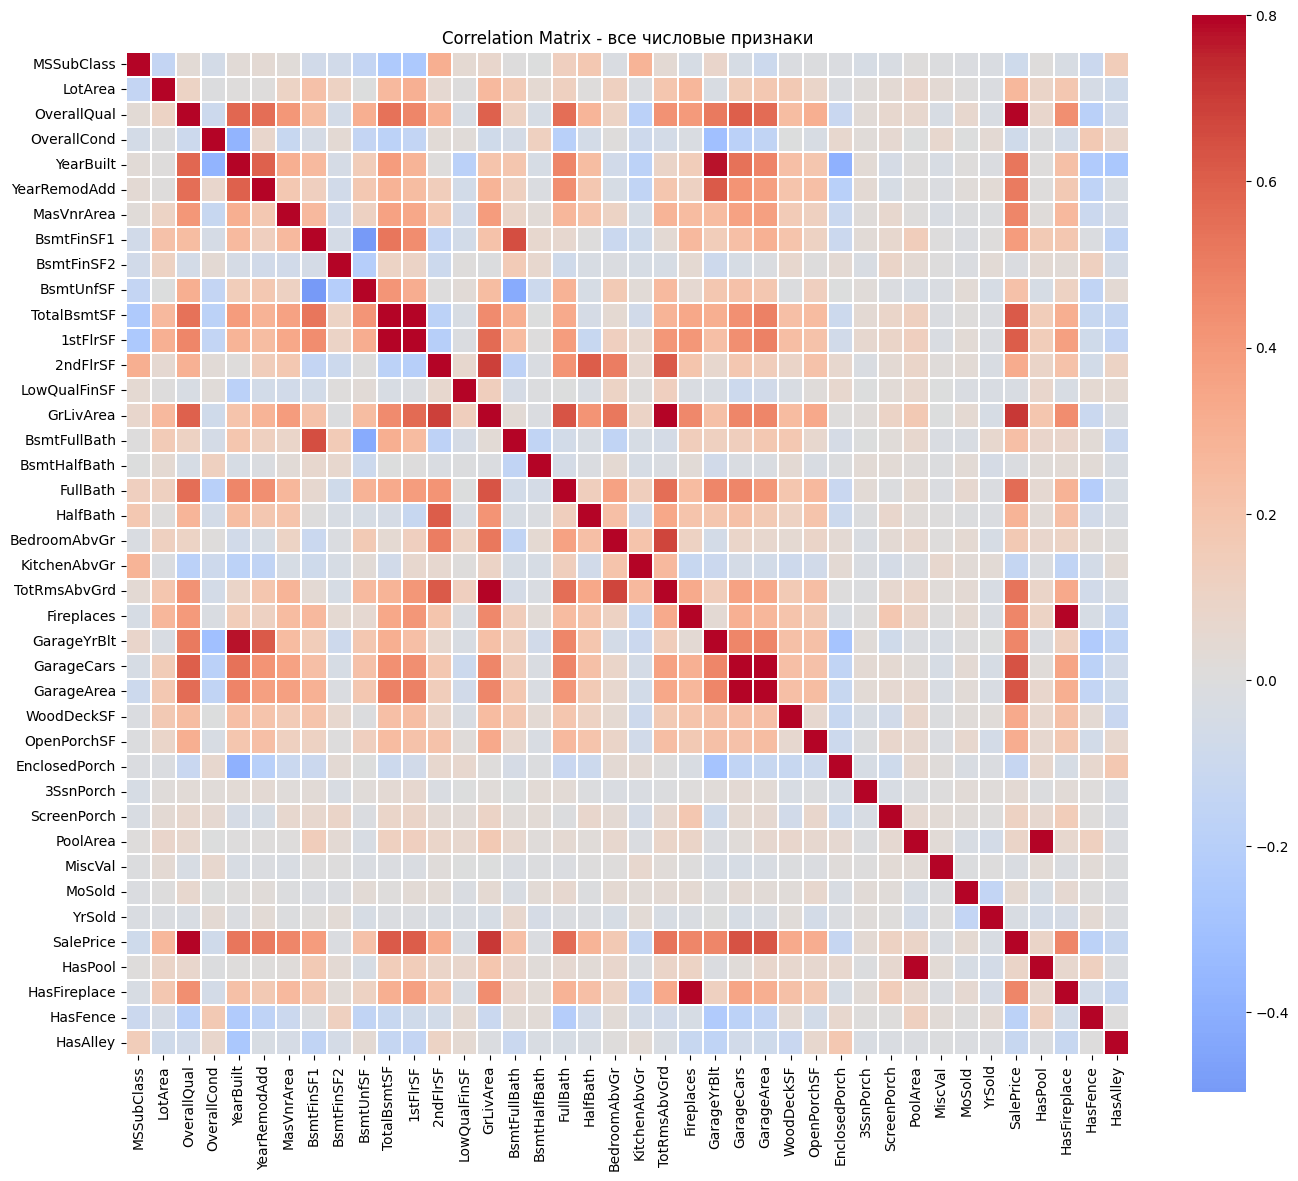

Смотрим на:
1. Строку/столбец SalePrice - сильные предикторы
2. Блоки красных ячеек - мультиколлинеарность (Garage*, Bsmt*, Living area*)


In [15]:
# Полная карта корреляций числовых признаков
num_df = df_clean.select_dtypes(include=np.number).drop(columns=['Id'])
corrmat = num_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corrmat, vmax=0.8, square=True, cmap='coolwarm', center=0,
            linewidths=0.1, ax=ax)
ax.set_title('Correlation Matrix - все числовые признаки')
plt.tight_layout()
plt.show()

print("Смотрим на:")
print("1. Строку/столбец SalePrice - сильные предикторы")
print("2. Блоки красных ячеек - мультиколлинеарность (Garage*, Bsmt*, Living area*)")

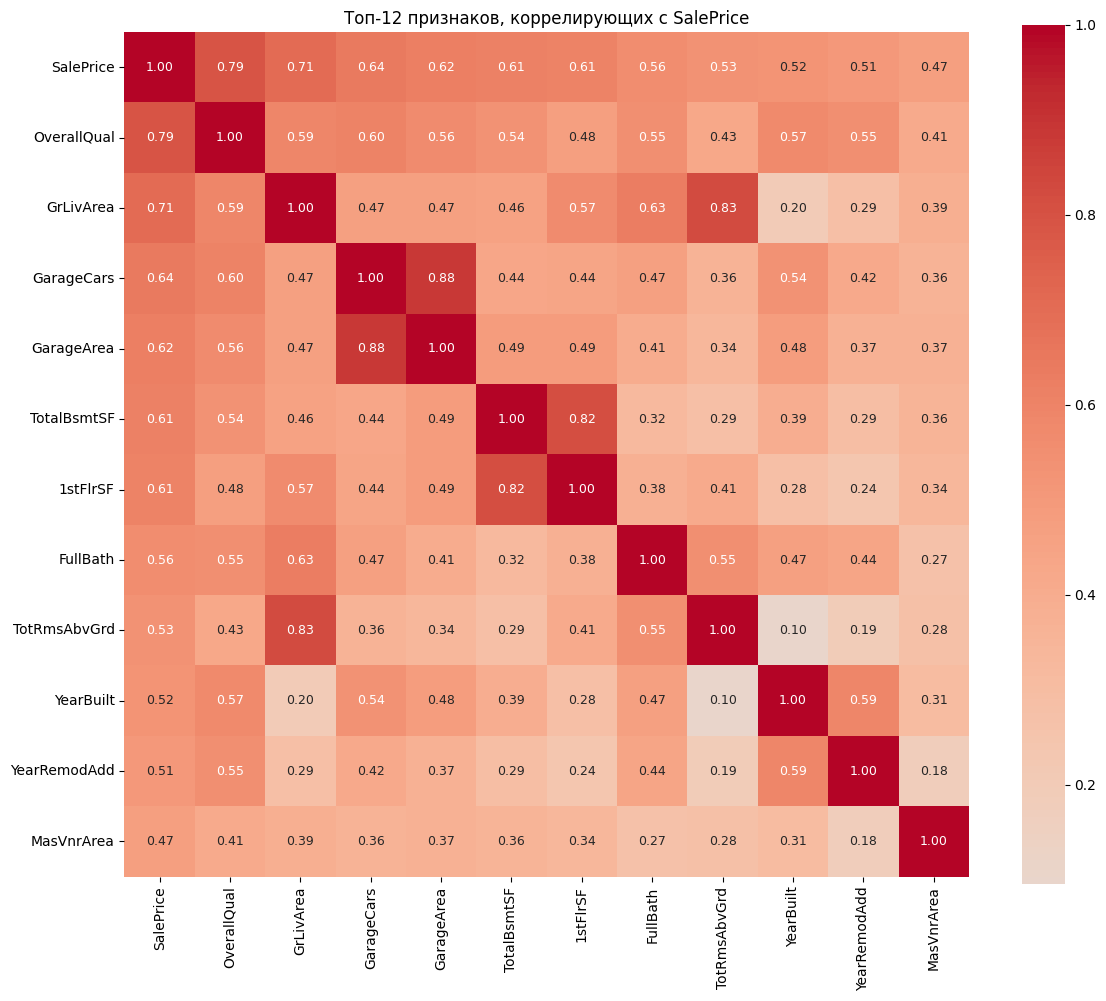


Корреляции с SalePrice (топ-12):
SalePrice       1.000000
OverallQual     0.791069
GrLivArea       0.708618
GarageCars      0.640473
GarageArea      0.623423
TotalBsmtSF     0.613905
1stFlrSF        0.605968
FullBath        0.560881
TotRmsAbvGrd    0.533779
YearBuilt       0.523273
YearRemodAdd    0.507430
MasVnrArea      0.472606


In [16]:
# Топ-12 признаков по корреляции с SalePrice
k = 12
cols_top = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm_top = np.corrcoef(df_clean[cols_top].values.T)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_top, cbar=True, annot=True, square=True, fmt='.2f',
            annot_kws={'size': 9}, yticklabels=cols_top, xticklabels=cols_top,
            cmap='coolwarm', center=0, ax=ax)
ax.set_title(f'Топ-{k} признаков, коррелирующих с SalePrice')
plt.tight_layout()
plt.show()

print("\nКорреляции с SalePrice (топ-12):")
print(corrmat['SalePrice'].sort_values(ascending=False).head(k).to_string())

In [17]:
# Выявляем мультиколлинеарность
threshold = 0.8
high_corr_pairs = []

for i in range(len(corrmat.columns)):
    for j in range(i+1, len(corrmat.columns)):
        if abs(corrmat.iloc[i, j]) >= threshold:
            high_corr_pairs.append({
                'Feature 1': corrmat.columns[i],
                'Feature 2': corrmat.columns[j],
                'Correlation': round(corrmat.iloc[i, j], 3)
            })

mc_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
print(f"Пар с |r| ≥ {threshold} (мультиколлинеарность): {len(mc_df)}")
print(mc_df.to_string(index=False))

Пар с |r| ≥ 0.8 (мультиколлинеарность): 5
  Feature 1    Feature 2  Correlation
   PoolArea      HasPool        0.990
 Fireplaces HasFireplace        0.900
 GarageCars   GarageArea        0.883
  GrLivArea TotRmsAbvGrd        0.826
TotalBsmtSF     1stFlrSF        0.819


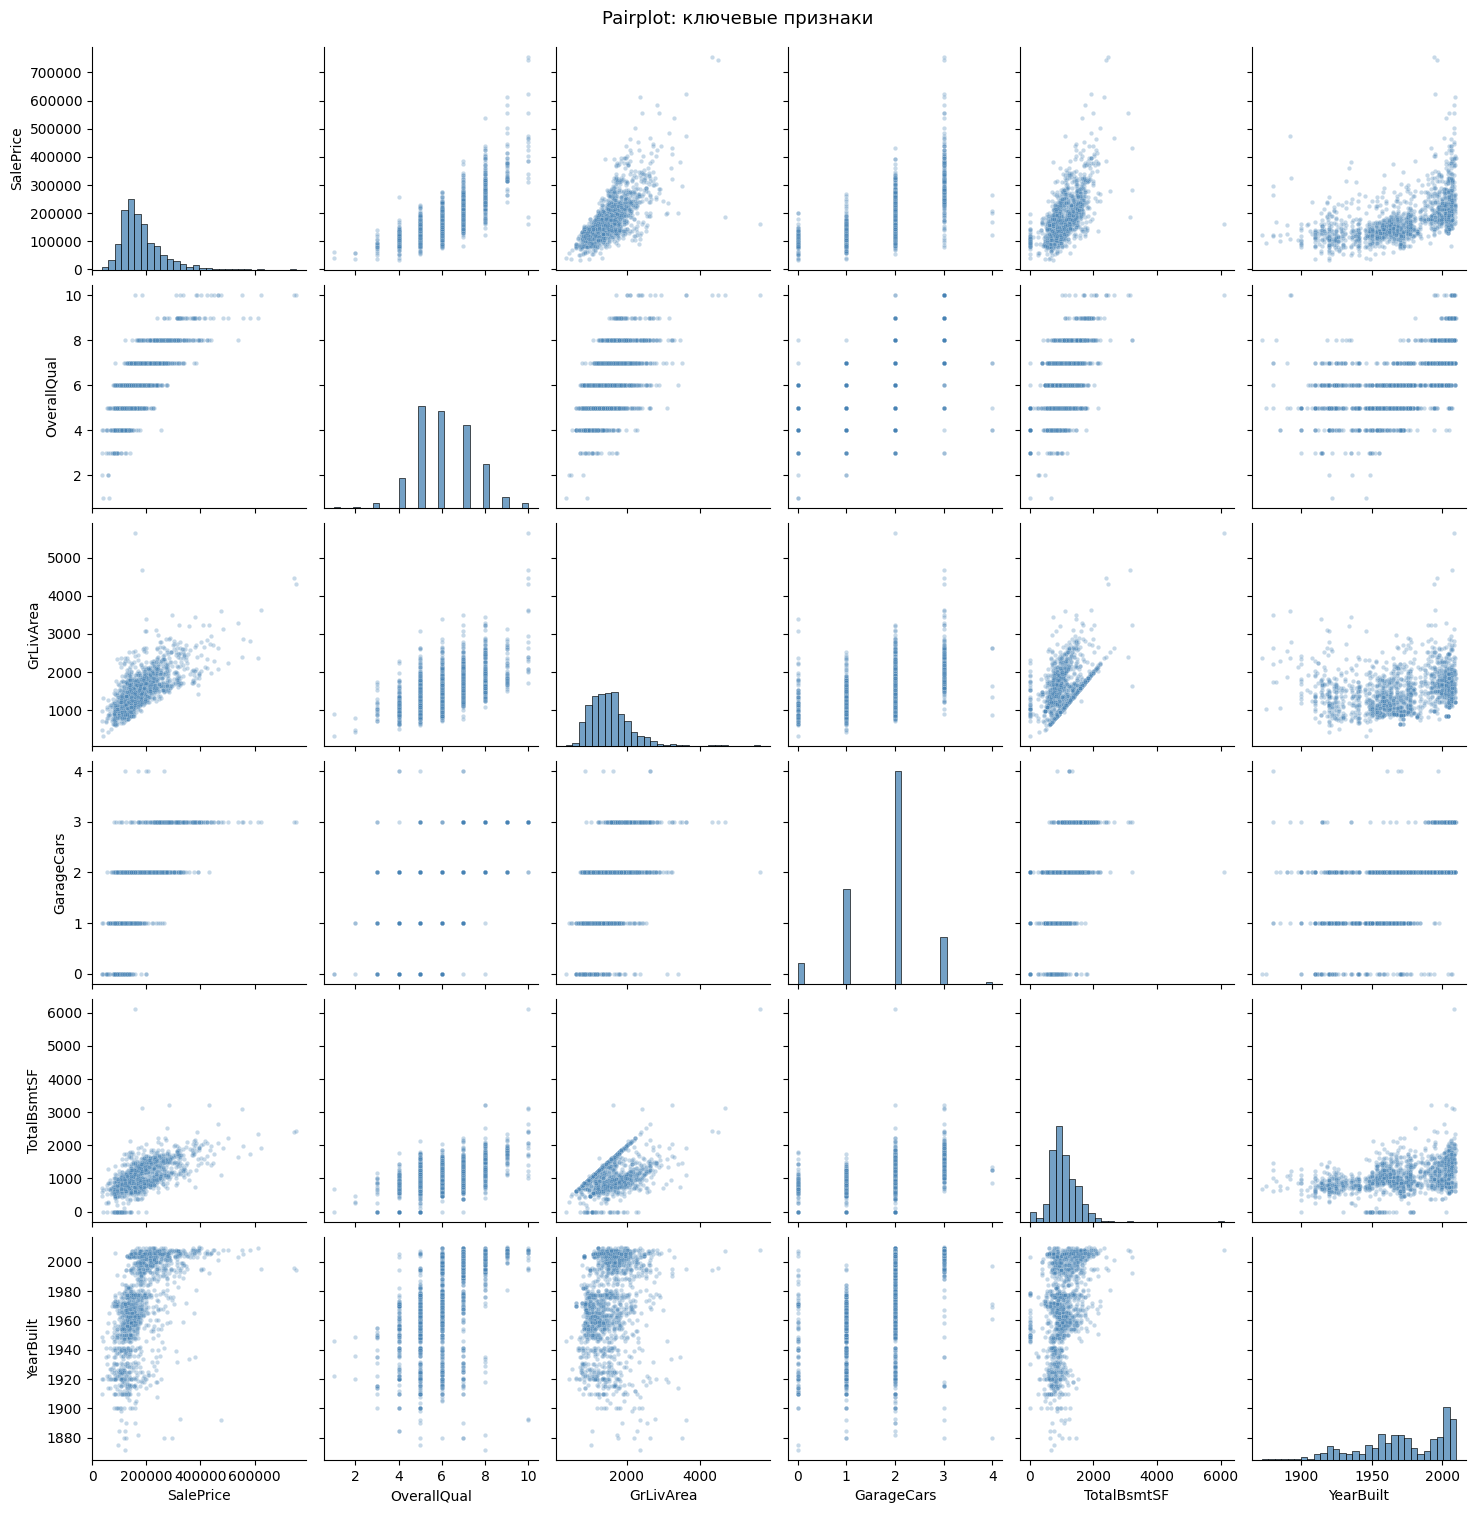

In [18]:
# Pairplot для ключевых признаков
pairplot_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
g = sns.pairplot(df_clean[pairplot_cols], diag_kind='hist',
                 plot_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'},
                 diag_kws={'color': 'steelblue', 'bins': 30})
g.figure.suptitle('Pairplot: ключевые признаки', y=1.01, fontsize=13)
plt.show()

---
## Шаг 7: Выбросы

### Univariate: Z-score

In [19]:
# Стандартизация SalePrice
z_scores = StandardScaler().fit_transform(df_clean[['SalePrice']])
z_low = z_scores[z_scores[:, 0].argsort()][:5]
z_high = z_scores[z_scores[:, 0].argsort()][-5:]

print("Нижние 5 значений (z-score):")
print(z_low.flatten().round(3))
print()
print("Верхние 5 значений (z-score):")
print(z_high.flatten().round(3))
print()

# Выбросы по правилу |z| > 3
outlier_mask = (np.abs(z_scores) > 3).flatten()
print(f"Выбросов (|z| > 3): {outlier_mask.sum()}")
print("Цены выбросов:", df_clean.loc[outlier_mask, 'SalePrice'].values)

Нижние 5 значений (z-score):
[-1.838 -1.833 -1.8   -1.783 -1.774]

Верхние 5 значений (z-score):
[5.06  5.422 5.59  7.1   7.226]

Выбросов (|z| > 3): 22
Цены выбросов: [438780 501837 475000 437154 426000 555000 440000 430000 446261 451950
 423000 755000 538000 485000 582933 611657 556581 424870 625000 745000
 465000 466500]


In [20]:
# IQR метод
Q1 = df_clean['SalePrice'].quantile(0.25)
Q3 = df_clean['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df_clean[(df_clean['SalePrice'] < lower_bound) | (df_clean['SalePrice'] > upper_bound)]

print(f"IQR метод:")
print(f"  Q1 = ${Q1:,.0f}, Q3 = ${Q3:,.0f}, IQR = ${IQR:,.0f}")
print(f"  Нижняя граница: ${lower_bound:,.0f}")
print(f"  Верхняя граница: ${upper_bound:,.0f}")
print(f"  Выбросов: {len(iqr_outliers)} ({len(iqr_outliers)/len(df_clean):.1%})")

IQR метод:
  Q1 = $129,950, Q3 = $214,000, IQR = $84,050
  Нижняя граница: $3,875
  Верхняя граница: $340,075
  Выбросов: 61 (4.2%)


### Bivariate: нарушение паттерна

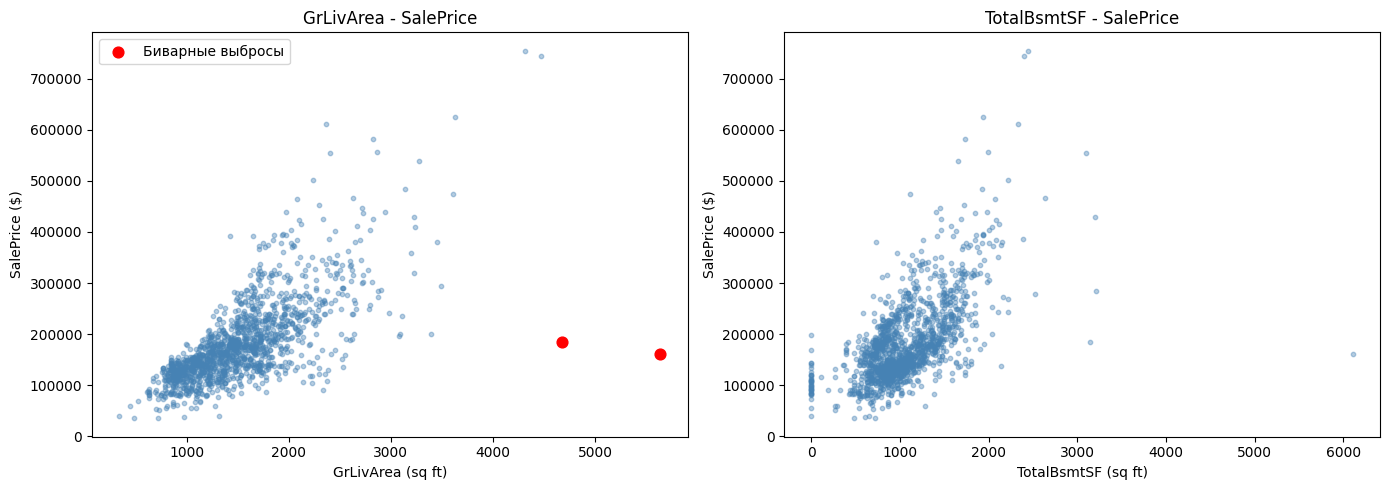

Биварные выбросы (большая площадь + низкая цена): 2 объекта
Вероятно - сельскохозяйственные участки или ошибки данных
Решение: изучить контекст, при необходимости удалить


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea - SalePrice
axes[0].scatter(df_clean['GrLivArea'], df_clean['SalePrice'], alpha=0.4, s=10, color='steelblue')
# Выбросы: большая площадь + неожиданно низкая цена
bivar_outliers = df_clean[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 200000)]
axes[0].scatter(bivar_outliers['GrLivArea'], bivar_outliers['SalePrice'],
                color='red', s=60, zorder=5, label='Биварные выбросы')
axes[0].set_xlabel('GrLivArea (sq ft)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title('GrLivArea - SalePrice')
axes[0].legend()

# TotalBsmtSF - SalePrice
axes[1].scatter(df_clean['TotalBsmtSF'], df_clean['SalePrice'], alpha=0.4, s=10, color='steelblue')
axes[1].set_xlabel('TotalBsmtSF (sq ft)')
axes[1].set_ylabel('SalePrice ($)')
axes[1].set_title('TotalBsmtSF - SalePrice')

plt.tight_layout()
plt.show()

print(f"Биварные выбросы (большая площадь + низкая цена): {len(bivar_outliers)} объекта")
print("Вероятно - сельскохозяйственные участки или ошибки данных")
print("Решение: изучить контекст, при необходимости удалить")

---
## Шаг 8: Проверка статистических предположений

### Нормальность и лог-трансформация

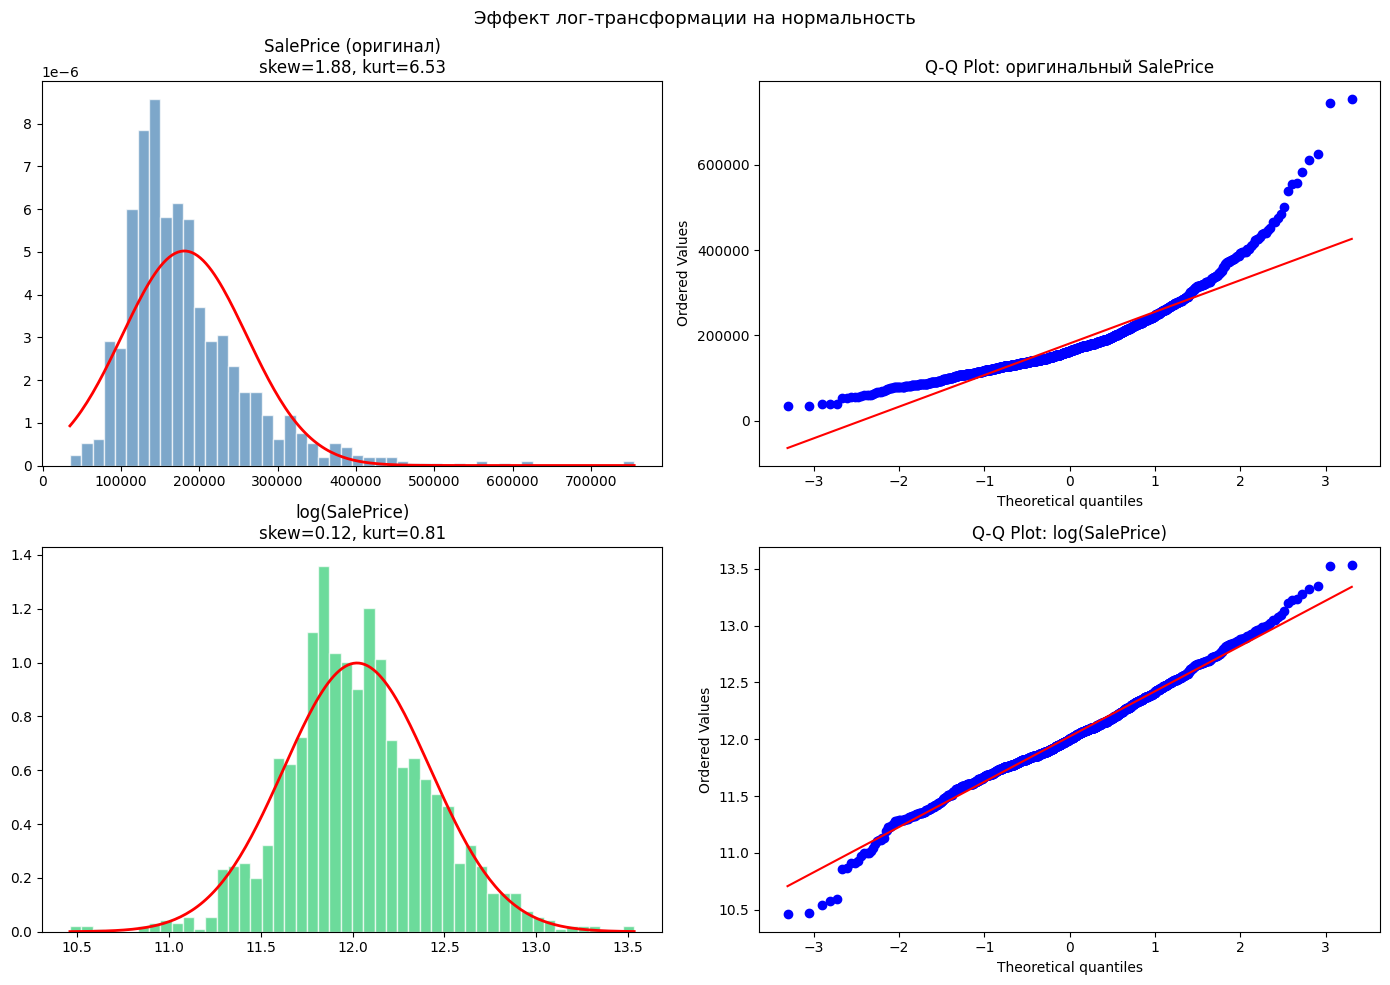

Shapiro-Wilk оригинал: p = 0.0000 →  НЕ нормальное
Shapiro-Wilk log:      p = 0.0000 →  НЕ нормальное (но значительно лучше!)


In [22]:
# Сравниваем оригинал и лог-трансформацию
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sp_orig = df_clean['SalePrice']
sp_log = np.log(df_clean['SalePrice'])

# Оригинальный SalePrice
axes[0, 0].hist(sp_orig, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
x = np.linspace(sp_orig.min(), sp_orig.max(), 200)
axes[0, 0].plot(x, norm.pdf(x, sp_orig.mean(), sp_orig.std()), 'r-', linewidth=2)
axes[0, 0].set_title(f'SalePrice (оригинал)\nskew={sp_orig.skew():.2f}, kurt={sp_orig.kurt():.2f}')

stats.probplot(sp_orig, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: оригинальный SalePrice')

# Лог-трансформация
axes[1, 0].hist(sp_log, bins=50, density=True, color='#2ecc71', alpha=0.7, edgecolor='white')
x_log = np.linspace(sp_log.min(), sp_log.max(), 200)
axes[1, 0].plot(x_log, norm.pdf(x_log, sp_log.mean(), sp_log.std()), 'r-', linewidth=2)
axes[1, 0].set_title(f'log(SalePrice)\nskew={sp_log.skew():.2f}, kurt={sp_log.kurt():.2f}')

stats.probplot(sp_log, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: log(SalePrice)')

plt.suptitle('Эффект лог-трансформации на нормальность', fontsize=13)
plt.tight_layout()
plt.show()

_, p_orig = stats.shapiro(sp_orig.sample(1000, random_state=42))
_, p_log = stats.shapiro(sp_log.sample(1000, random_state=42))
print(f"Shapiro-Wilk оригинал: p = {p_orig:.4f} → {'нормальное' if p_orig > 0.05 else ' НЕ нормальное'}")
print(f"Shapiro-Wilk log:      p = {p_log:.4f} → {'нормальное' if p_log > 0.05 else ' НЕ нормальное'} (но значительно лучше!)") 

In [23]:
# Трансформируем другие скошенные переменные
vars_to_transform = {
    'GrLivArea': 'log',
    'TotalBsmtSF': 'has_zero',   # нули нельзя логарифмировать
    'LotArea': 'log'
}

df_transformed = df_clean.copy()
df_transformed['SalePrice_log'] = np.log(df_transformed['SalePrice'])
df_transformed['GrLivArea_log'] = np.log(df_transformed['GrLivArea'])
df_transformed['LotArea_log'] = np.log(df_transformed['LotArea'])

# TotalBsmtSF с нулями - создаём бинарный признак + логарифм только для ненулевых
df_transformed['HasBsmt'] = (df_transformed['TotalBsmtSF'] > 0).astype(int)
df_transformed['TotalBsmtSF_log'] = 0.0
df_transformed.loc[df_transformed['TotalBsmtSF'] > 0, 'TotalBsmtSF_log'] = \
    np.log(df_transformed.loc[df_transformed['TotalBsmtSF'] > 0, 'TotalBsmtSF'])

# Сравниваем skewness до и после
result = pd.DataFrame({
    'Оригинал': [
        df_clean['SalePrice'].skew(),
        df_clean['GrLivArea'].skew(),
        df_clean['LotArea'].skew()
    ],
    'После log': [
        df_transformed['SalePrice_log'].skew(),
        df_transformed['GrLivArea_log'].skew(),
        df_transformed['LotArea_log'].skew()
    ]
}, index=['SalePrice', 'GrLivArea', 'LotArea'])

print("Skewness до и после лог-трансформации:")
print(result.round(4))
print()
print(" Значения приближаются к 0 - нормальность улучшилась")

Skewness до и после лог-трансформации:
           Оригинал  После log
SalePrice    1.8819     0.1213
GrLivArea    1.3657    -0.0072
LotArea     12.2034    -0.1377

 Значения приближаются к 0 - нормальность улучшилась


### Гомоскедастичность

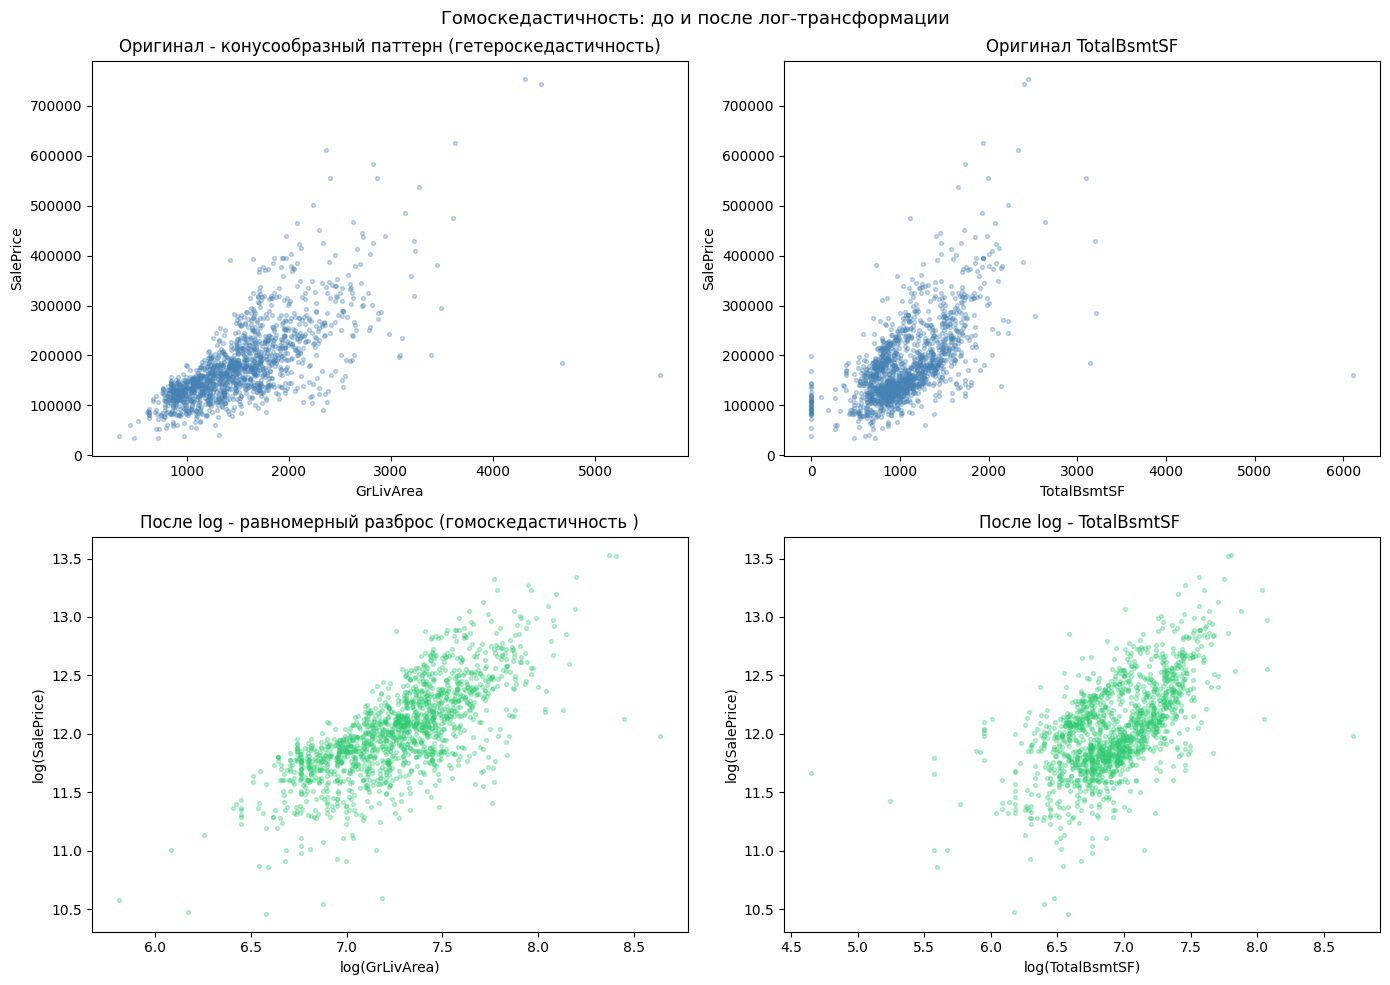

Лог-трансформация решила сразу: нормальность + гомоскедастичность + частично линейность


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# До трансформации
axes[0, 0].scatter(df_clean['GrLivArea'], df_clean['SalePrice'], alpha=0.3, s=8, color='steelblue')
axes[0, 0].set_xlabel('GrLivArea')
axes[0, 0].set_ylabel('SalePrice')
axes[0, 0].set_title('Оригинал - конусообразный паттерн (гетероскедастичность)')

axes[0, 1].scatter(df_clean['TotalBsmtSF'], df_clean['SalePrice'], alpha=0.3, s=8, color='steelblue')
axes[0, 1].set_xlabel('TotalBsmtSF')
axes[0, 1].set_ylabel('SalePrice')
axes[0, 1].set_title('Оригинал TotalBsmtSF')

# После трансформации
axes[1, 0].scatter(df_transformed['GrLivArea_log'], df_transformed['SalePrice_log'],
                   alpha=0.3, s=8, color='#2ecc71')
axes[1, 0].set_xlabel('log(GrLivArea)')
axes[1, 0].set_ylabel('log(SalePrice)')
axes[1, 0].set_title('После log - равномерный разброс (гомоскедастичность )')

bsmt_nonzero = df_transformed[df_transformed['TotalBsmtSF_log'] > 0]
axes[1, 1].scatter(bsmt_nonzero['TotalBsmtSF_log'], bsmt_nonzero['SalePrice_log'],
                   alpha=0.3, s=8, color='#2ecc71')
axes[1, 1].set_xlabel('log(TotalBsmtSF)')
axes[1, 1].set_ylabel('log(SalePrice)')
axes[1, 1].set_title('После log - TotalBsmtSF ')

plt.suptitle('Гомоскедастичность: до и после лог-трансформации', fontsize=13)
plt.tight_layout()
plt.show()
print("Лог-трансформация решила сразу: нормальность + гомоскедастичность + частично линейность")

---
## Итоги EDA:

In [30]:
# Финальные топ-предикторы после EDA
df_for_corr = df_transformed.copy()
df_for_corr['SalePrice_log'] = np.log(df_for_corr['SalePrice'])

final_features = ['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars',
                  'TotalBsmtSF', 'FullBath', 'TotalBaths', 'YearBuilt',
                  'HouseAge', 'WasRemodeled']


for feat in final_features:
    if feat in df_for_corr.columns:
        r, p = stats.pearsonr(df_for_corr[feat], df_for_corr['SalePrice_log'])
        sig = '1' if p < 0.001 else '2' if p < 0.05 else '3'
        print(f"{sig} {feat:<25} r = {r:>6.3f}  (p = {p:.1e})")

print()
print("Обнаруженные проблемы:")
print(f"    Мультиколлинеарность: {len(mc_df)} пар признаков с |r|≥0.8")
print(f"    SalePrice сильно скошен (skew={sp.skew():.2f}) → нужна log()")
print(f"    19 колонок с пропусками - обработаны")
print(f"    Биварные выбросы: 2 объекта с аномально низкой ценой")
print()
print("Рекомендации перед моделированием:")
print("   Использовать log(SalePrice) как целевую")
print("   Удалить 1 из пары GarageCars/GarageArea")
print("   Удалить 1 из пары TotalBsmtSF/1stFlrSF")

1 OverallQual               r =  0.817  (p = 0.0e+00)
1 GrLivArea                 r =  0.701  (p = 4.2e-216)
1 GarageCars                r =  0.681  (p = 4.1e-199)
1 TotalBsmtSF               r =  0.613  (p = 4.6e-151)
1 FullBath                  r =  0.595  (p = 2.2e-140)
1 YearBuilt                 r =  0.587  (p = 9.7e-136)

Обнаруженные проблемы:
    Мультиколлинеарность: 5 пар признаков с |r|≥0.8
    SalePrice сильно скошен (skew=1.88) → нужна log()
    19 колонок с пропусками - обработаны
    Биварные выбросы: 2 объекта с аномально низкой ценой

Рекомендации перед моделированием:
   Использовать log(SalePrice) как целевую
   Удалить 1 из пары GarageCars/GarageArea
   Удалить 1 из пары TotalBsmtSF/1stFlrSF
